In [72]:
import config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import constants as const
import astropy.units as u
import matplotlib.gridspec as gridspec
from catalog.manipulate.parallax_zeropoint_correction import correct_zp
from computation.distance_estimate import estimate_distances_df
from astropy.coordinates import SkyCoord, Galactocentric

In [16]:
df_co = pd.read_csv(config.RESULTS_CATALOGUE_DIR / "known_co_binaries_zp_corrected.csv")
df_hvx = pd.read_csv(config.RESULTS_CATALOGUE_DIR / "high-v_sources" / "combined_vpec_lolim_gt_150_unique_stage_6.csv")
df_all = pd.read_csv(config.RESULTS_CATALOGUE_DIR / "high-v_sources" / "combined_vpec_med_gt_0_unique.csv")

In [17]:
gc_frame = Galactocentric(galcen_distance=const.R_0 * u.kpc, z_sun=25.0 * u.pc)
gc_frame.representation_type = "cylindrical"

In [20]:
dist_estimate = df_co.apply(estimate_distances_df, axis=1, result_type="expand")
dist_estimate.columns = ["dist_med", "e_dist", "E_dist", "distance_inference"]
df_co_w_dist = pd.concat([df_co, dist_estimate], axis=1)


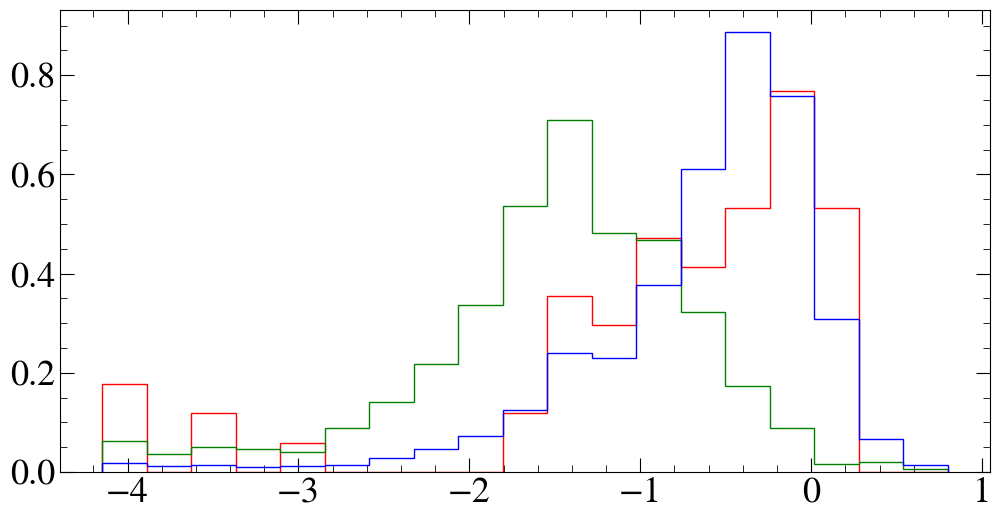

In [45]:
plt.style.use("mycustomised")
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

bins = np.linspace(df_all.mh_gspphot.min(), df_all.mh_gspphot.max(), 20)

_ = ax.hist(df_co.mh_gspphot, bins=bins, density=True, ec="r", histtype="step", cumulative=False)
_ = ax.hist(df_hvx.mh_gspphot, bins=bins, density=True, ec="g", histtype="step", cumulative=False)
_ = ax.hist(df_all.mh_gspphot, bins=bins, density=True, ec="b", histtype="step", cumulative=False)

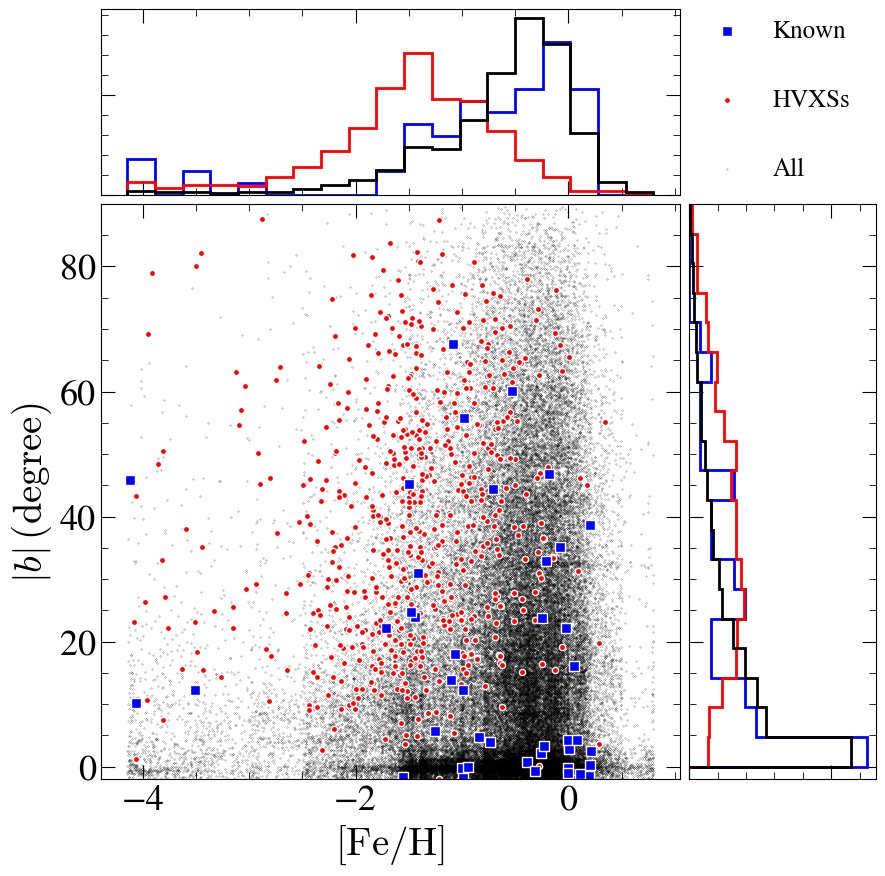

In [161]:
plt.style.use("mycustomised")
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)

ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_xhist = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_yhist = fig.add_subplot(gs[1:4, 3], sharey=ax_main)
ax_yhist.tick_params(labelleft=False, labelbottom=False)
ax_xhist.tick_params(labelbottom=False, labelleft=False)

df_dict = {"Known": df_co_w_dist, "HVXSs": df_hvx, "All": df_all}
style_dict = {
    "Known": {"s": 50, "marker": "s", "ec": "w", "fc": "b", "zorder": 2, "label": "Known", "rasterized": True},
    "HVXSs": {"s": 20, "marker": "o", "ec": "w", "fc": "r", "label": "HVXSs", "rasterized": True},
    "All": {"s": 0.1, "marker": ".", "c": "k", "fc": "k", "zorder": -9, "label": "All", "rasterized": True}
}

bins_x = np.linspace(df_all.mh_gspphot.min(), df_all.mh_gspphot.max(), 20)
bins_y = np.linspace(0, 90, 20)
for key, val in style_dict.items():
    df_indiv = df_dict[key]
    coords = SkyCoord(df_indiv.ra.values * u.deg, df_indiv.dec.values * u.deg, distance=df_indiv.dist_med.values * u.kpc, frame="icrs")
    coords_gal = coords.galactic
    coords_gc = coords.transform_to(gc_frame)
    z = coords_gc.z.value
    # y = np.abs(z)
    y = coords_gal.b.deg
    x = df_indiv["mh_gspphot"]
    ax_main.scatter(x, y, **val)
    _ = ax_xhist.hist(x, bins=bins_x, density=True, histtype="step", ec=val["fc"], lw=2.0)
    _ = ax_yhist.hist(y, bins=bins_y, density=True, histtype="step", lw=2.0, ec=val["fc"], orientation="horizontal")
    
ax_yhist.invert_yaxis()
# ax_main.set_yscale("log")
ax_main.set_ylim(-2, 90)

# ax_main.set_yticks([0.1, 1, 10])
# ax_main.set_yticklabels(["0.1", "1", "10"])

ax_main.set_xlabel("$\mathrm{[Fe/H]}$")
ax_main.set_ylabel(r"$|b|\,(\mathrm{degree})$")
 
ax_legend = fig.add_subplot(gs[0, 3])  # Upper right corner of the grid
ax_legend.axis("off")  # Hide axis lines and ticks for the legend box
bbox_xhist = ax_xhist.get_position(fig)
bbox_yhist = ax_yhist.get_position(fig)

# Calculate width and height of the legend box to match the histogram sizes
legend_width = bbox_yhist.width
legend_height = bbox_xhist.height

# Place legend in ax_legend and use calculated bbox_to_anchor
handles, labels = ax_main.get_legend_handles_labels()
legend = ax_legend.legend(
    handles, labels,
    loc="lower left",
    frameon=False,
    bbox_to_anchor=(1.0, 1.0, legend_width, legend_height),
    bbox_transform=ax_main.transAxes,
    fontsize=18,
    labelspacing=1.8,
    borderpad=0.4
)


# ax_main.legend(loc="upper left", bbox_to_anchor=(0.99, 1.02), ncol=1, handletextpad=0.1, labelspacing=1.5, fontsize=18)
plt.savefig(config.RESULTS_FIGURES_DIR / "high-v_sources" / "z_vs_mh.pdf")

In [117]:
np.log10(90)

np.float64(1.954242509439325)